In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
from sqlalchemy.ext.asyncio import result

warnings.filterwarnings('ignore')

#### Loading the Dataset

In [2]:
# Create database conncetion
conn = sqlite3.connect('inventory.db')

# Fetching vendor summary data
df = pd.read_sql_query('select * from vendor_sales_summary',conn)
df.head()

,index,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesDollars,TotalSalesPrice,TotalSalesQuantity,TotalExciseTax,FreightCost,SalestoPurchaseRatio,GrossProfit,ProfitMargin,StockTurnover
0,0,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,52747,852918.99,183154.71,21132.39,8329.0,15303.88,257032.07,0.214739,-669764.28,-365.682258,0.157905
1,1,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,28772,755840.44,138165.61,29727.74,3839.0,7053.50,68601.68,0.182797,-617674.83,-447.053959,0.133428
2,2,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,28326,620056.14,148816.57,24501.88,4943.0,9082.28,257032.07,0.240005,-471239.57,-316.657997,0.174504
3,3,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,27600,503424.00,117084.76,22231.41,4524.0,8311.97,123780.22,0.232577,-386339.24,-329.965437,0.163913
4,4,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,20653,478943.07,106254.57,23662.11,3543.0,6509.61,144929.24,0.221852,-372688.50,-350.750561,0.171549


#### Exploratory Data Analysis
* Previously,we examined the various tables in the database to identify key variables,understand their relationships,and determine which ones should be included in the final analysis.
* In this phase of EDA,we will analyze the resultant table to gain insights into the distribution of each column.This will help us understand data patterns,identify anomalies,and ensure data quality before proceeding with further analysis.

In [3]:
# summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
index,7153.0,3.576000e+03,2065.037570,0.00,1788.000000,3576.000000,5364.000000,7152.000000
VendorNumber,7153.0,9.994507e+03,17271.467731,2.00,3252.000000,7153.000000,9552.000000,173357.000000
Brand,7153.0,1.732448e+04,13081.396153,58.00,5137.000000,16661.000000,24703.000000,90604.000000
PurchasePrice,7153.0,1.875851e+01,94.447376,0.38,6.660000,9.920000,17.030000,5681.810000
ActualPrice,7153.0,2.755945e+01,126.498322,0.49,9.990000,14.990000,24.990000,7499.990000
Volume,7153.0,8.630175e+02,608.020965,50.00,750.000000,750.000000,750.000000,18000.000000
TotalPurchaseQuantity,7153.0,9.188381e+02,2837.825247,1.00,24.000000,156.000000,696.000000,77244.000000
TotalPurchaseDollars,7153.0,8.335182e+03,27634.082789,0.71,285.090000,1785.500000,7081.250000,852918.990000
TotalSalesDollars,7153.0,1.802466e+03,6023.400383,0.00,41.970000,351.780000,1513.990000,183154.710000
TotalSalesPrice,7153.0,8.983252e+02,1982.548251,0.00,21.980000,203.880000,911.710000,29727.740000


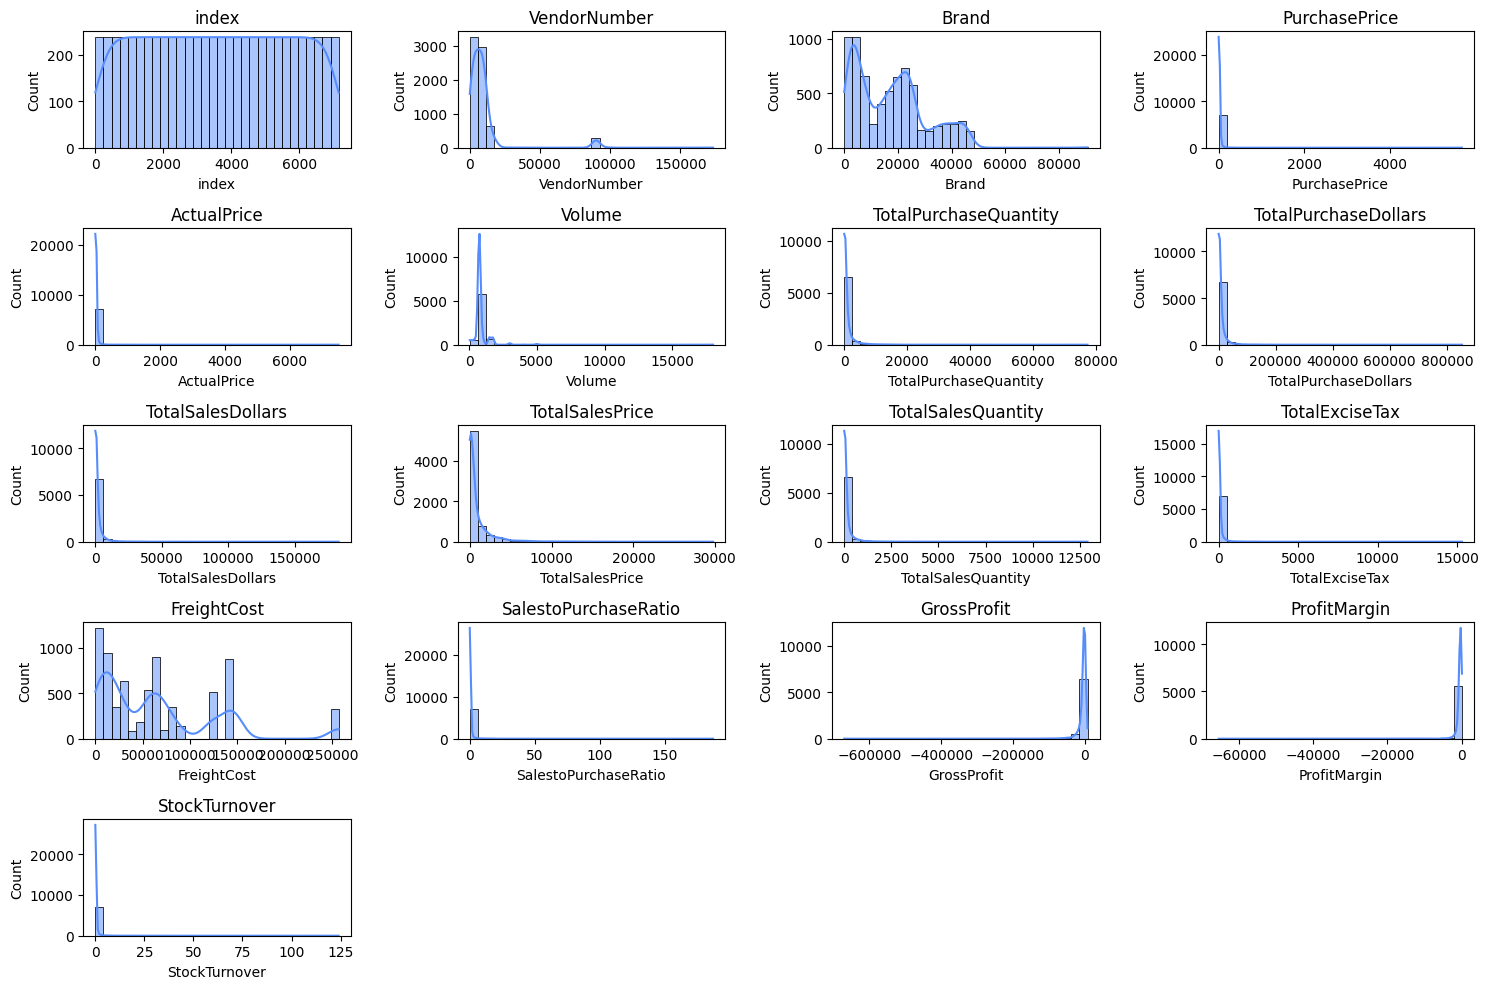

In [4]:
# Distribution plots for numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize = (15,10))
for i,col in enumerate(numerical_cols):
    plt.subplot(5,4,i+1)   #Adjust grid layout
    sns.histplot(df[col],kde=True,bins=30)
    plt.title(col)
plt.tight_layout(),
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

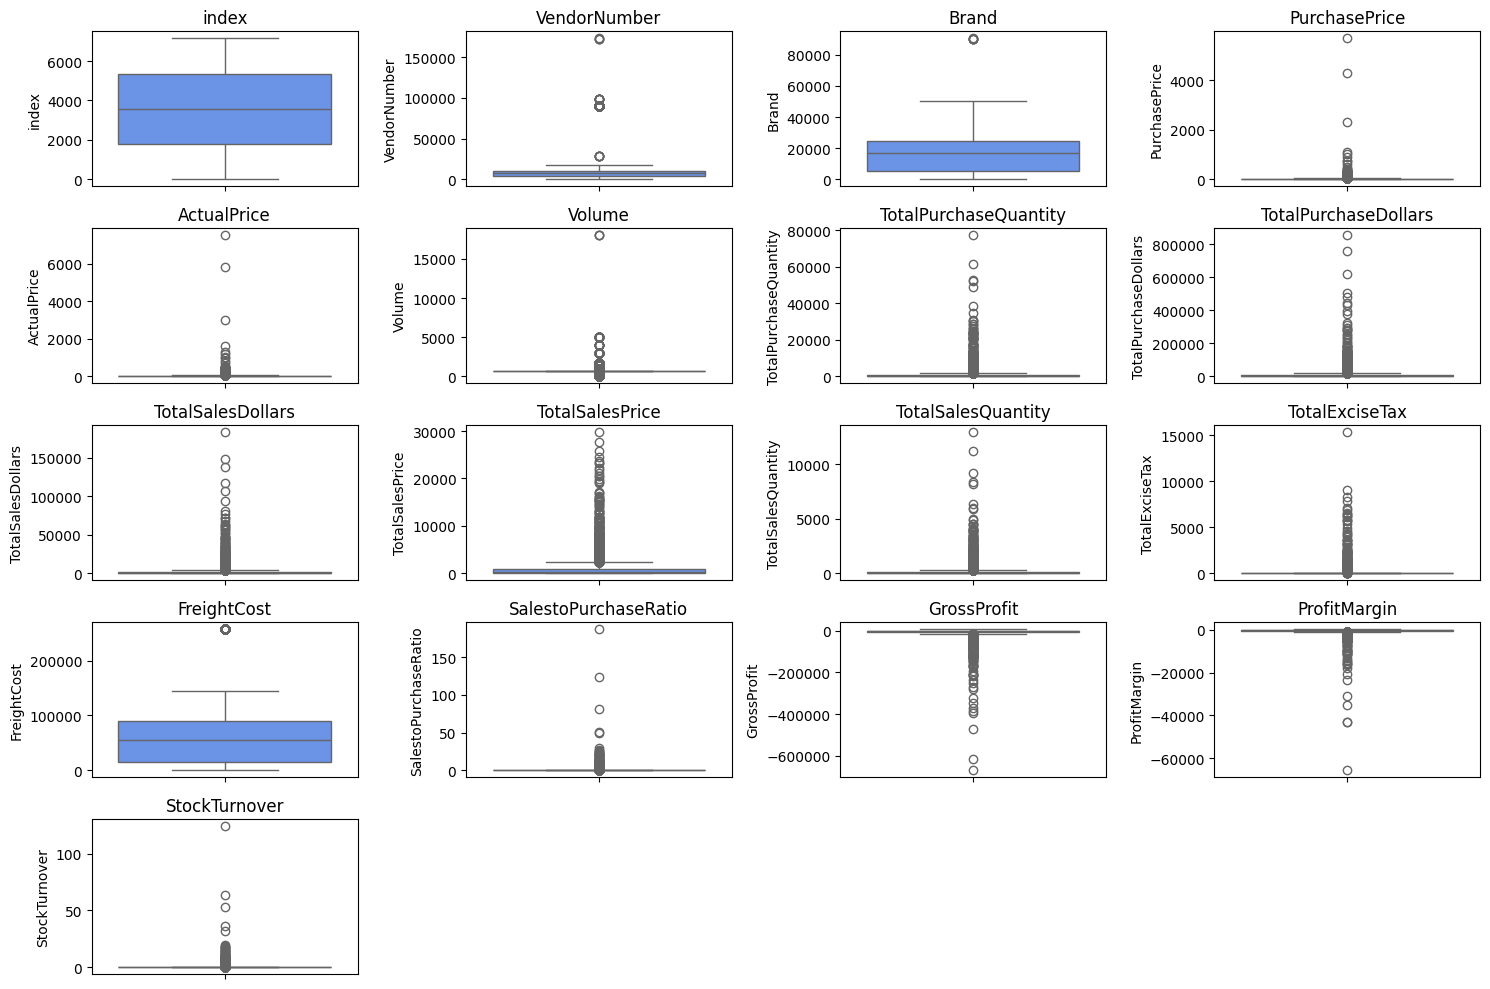

In [5]:
# Outlier detection with Boxplot
plt.figure(figsize = (15,10)),
for i,col in enumerate(numerical_cols):
    plt.subplot(5,4,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show

#### Summary Insights:

##### Negative & Zero Values:

* Gross Profit:- Minimum value is -52,0002.78,indicating losses.SOme products or transactions may be selling at a loss due to high costs or selling at discounts lower than the purchase price.
* Profit Margin:- Has a minimum of -∞,which suggests cases where revenue is zero or even lower than costs
* Total Sales Quantity & Sales Dollars:- Minimum values are 0,meaning some products were purchased but never sold. These could be slow-moving or obsolete stock

#### Outliers Indicated by high Standard Deviations

* Purchase & Actual Prices:- The max values (5681.81 & 7499.99) are significantly higher than the mean(24.39,35.64),indicating potential premimum products.
* Freight Cost:- Huge variation,from 0.09 to 257032.07,suggests logistics inefficients or bulk shipments.
* Stock Turnover:- Ranges from 0 to 274.5,implying some products sell extremly fasts while others remain in stock indefinetly.Value more than 1 indicates that sold qty for that product is higher than purchased qty due toeither sales are being fulfilled from older stock.


In [6]:
# Lets filter the data by removing inconsistance
df = pd.read_sql_query("""SELECT *
FROM vendor_sales_summary
WHERE GrossProfit > 0
AND ProfitMargin > 0
AND TotalSalesQuantity > 0""",conn)
df.shape

(550, 19)

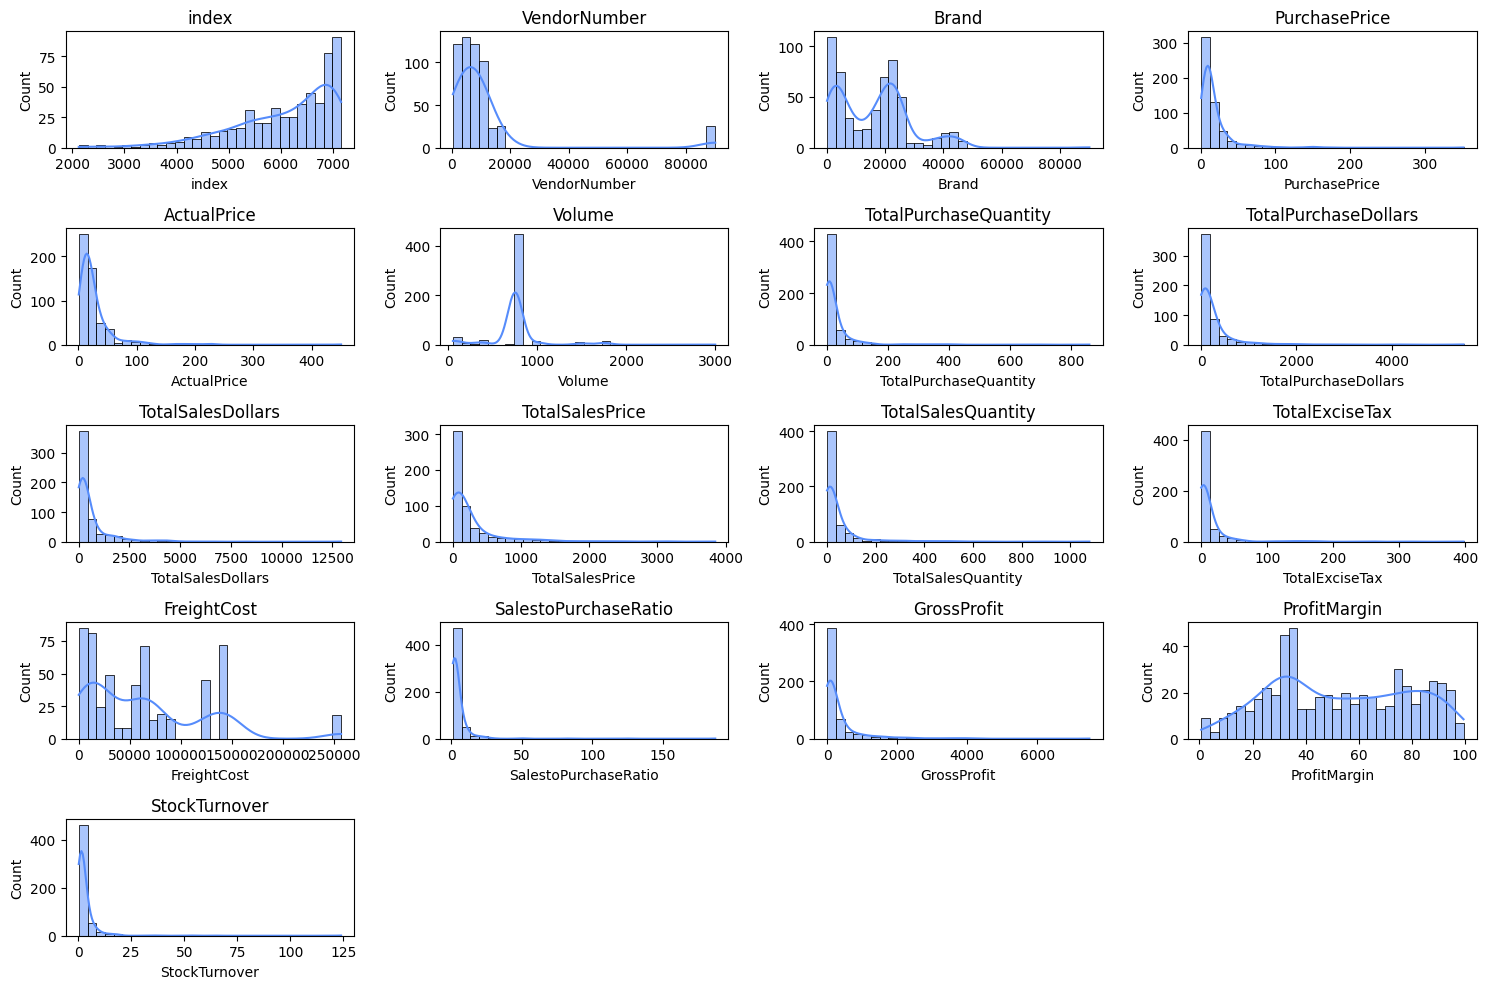

In [7]:
# Distribution plots for numerical columns after cleaning the data
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize = (15,10))
for i,col in enumerate(numerical_cols):
    plt.subplot(5,4,i+1)   #Adjust grid layout
    sns.histplot(df[col],kde=True,bins=30)
    plt.title(col)
plt.tight_layout(),
plt.show()

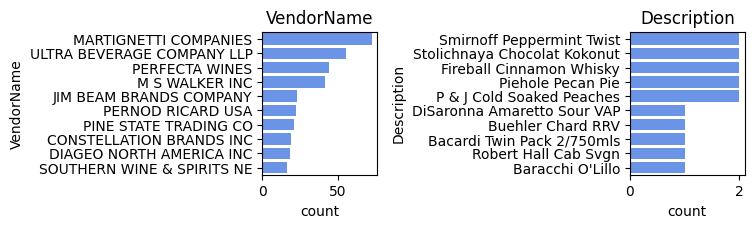

In [8]:
# Count plot for categorical value
categorical_cols = ['VendorName','Description']

plt.figure(figsize = (15,10))
for i,col in enumerate(categorical_cols):
    plt.subplot(5,4,i+1)   #Adjust grid layout
    sns.countplot(df[col], order = df[col].value_counts().index[:10])
    plt.title(col)
plt.tight_layout(),
plt.show()

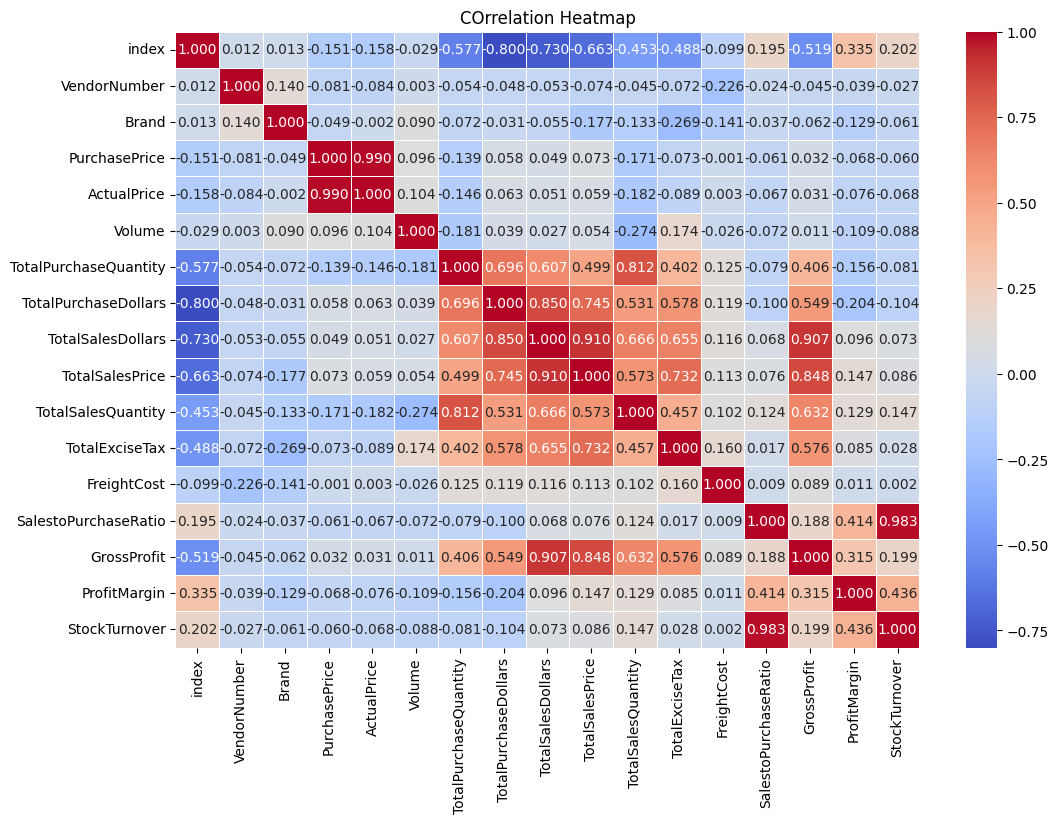

In [9]:
# Correlation Heatmap
plt.figure(figsize=(12,8))
correlaion_matrix = df[numerical_cols].corr()
sns.heatmap(correlaion_matrix,annot=True,fmt = ".3f",cmap='coolwarm',linewidths=0.7)
plt.title('COrrelation Heatmap')
plt.show()

#### Correlation Insights

* Purchase Price has weak correlations with TotalSalesDollars(-0.009) and GrossProfit(-0.007),suggesting that price variations do not significantly impact sales revenue or profit.
* Strong correlation between total purchases quantity and total sales qty (0.933),confirming efficient turnover turnover



### Data Analysis

#### 1st Research Question :- Identify Brands that need Promotional or Pricing Adjustments which exhibit lower sales performance but higher profit margins.


In [10]:
brand_performance = df.groupby('Description').agg({
    'TotalSalesDollars':'sum',
    'ProfitMargin':'mean'}).reset_index()
brand_performance

,Description,TotalSalesDollars,ProfitMargin
0,12 Days of Pearls Gift Set,49.95,85.605606
1,1800 Select Silver Tequila,269.91,92.430810
2,A Bichot Chablis Vaucopins,115.96,65.746809
3,A Bichot Merc Champs M,171.96,83.658990
4,Absolut Grapevine Vodka,499.66,43.361486
...,...,...,...
540,Yellow Tail Moscato Bubbles,38.97,34.642032
541,Z-52 Znfdl Lodi Old Vines,759.05,97.948752
542,Zardetto Pros di Coneg Brut,60.39,35.618480
543,Zinsane Znfdl Lodi,3691.38,94.547297


In [11]:
low_sales_threshold = brand_performance['TotalSalesDollars'].quantile(0.15)  # less than 15%
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)  # greater than than 85%

print(f'Sales Threshold is {low_sales_threshold}\n'
     f'Margin Threshold is {high_margin_threshold}')

Sales Threshold is 67.704
Margin Threshold is 84.93941455002812


In [12]:
# Filter brands with low sales but high profit margins
target_brands = brand_performance[
    (brand_performance['TotalSalesDollars'] <= low_sales_threshold) &
    (brand_performance['ProfitMargin'] >= high_margin_threshold)
]
target_brands

,Description,TotalSalesDollars,ProfitMargin
0,12 Days of Pearls Gift Set,49.95,85.605606
6,Absolut Pears,35.82,91.122278
337,Mojoshot Blue Lagoon RTD,48.51,95.485467
360,Old St Nick's Egg Nog,59.90,94.323873
381,Piehole Apple Pie,52.47,91.766724
452,St Elder Elderflower Liqueur,48.51,88.291074
488,Three Olives Grape Vodka,5.94,88.047138


In [13]:
print('Brands with low sales but high profit margins:')
target_brands = target_brands.sort_values('TotalSalesDollars')
target_brands.to_csv(r'brand need Promotion_Pricing Adjustment.csv',index=False)
target_brands

Brands with low sales but high profit margins:


,Description,TotalSalesDollars,ProfitMargin
488,Three Olives Grape Vodka,5.94,88.047138
6,Absolut Pears,35.82,91.122278
452,St Elder Elderflower Liqueur,48.51,88.291074
337,Mojoshot Blue Lagoon RTD,48.51,95.485467
0,12 Days of Pearls Gift Set,49.95,85.605606
381,Piehole Apple Pie,52.47,91.766724
360,Old St Nick's Egg Nog,59.90,94.323873


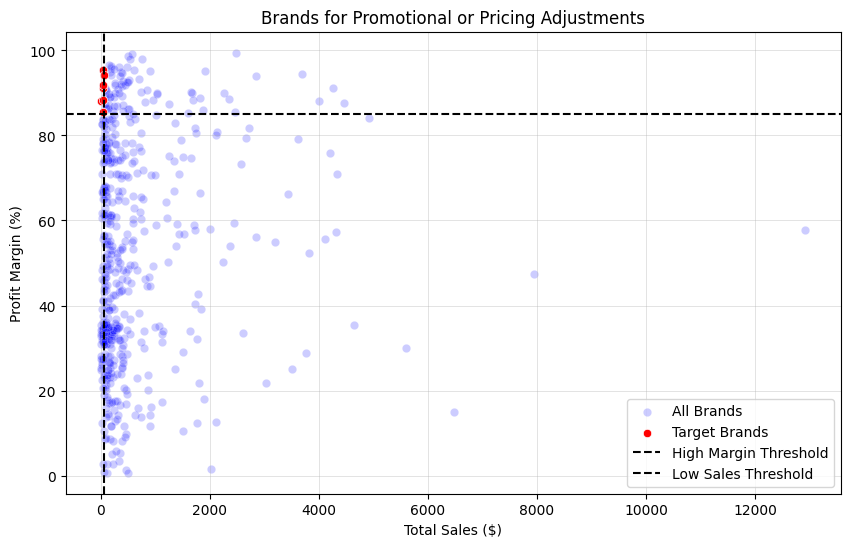

In [14]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=brand_performance,x = 'TotalSalesDollars' , y = 'ProfitMargin', color = 'blue',label = 'All Brands', alpha = 0.2)
sns.scatterplot(data=target_brands,x = 'TotalSalesDollars' , y = 'ProfitMargin', color = 'red',label = 'Target Brands')

plt.axhline(high_margin_threshold,linestyle = '--',color = 'black',label = "High Margin Threshold")
plt.axvline(low_sales_threshold,linestyle = '--',color = 'black',label = "Low Sales Threshold")

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
# To see better visualization
brand_performance = brand_performance[brand_performance['TotalSalesDollars']<1000]

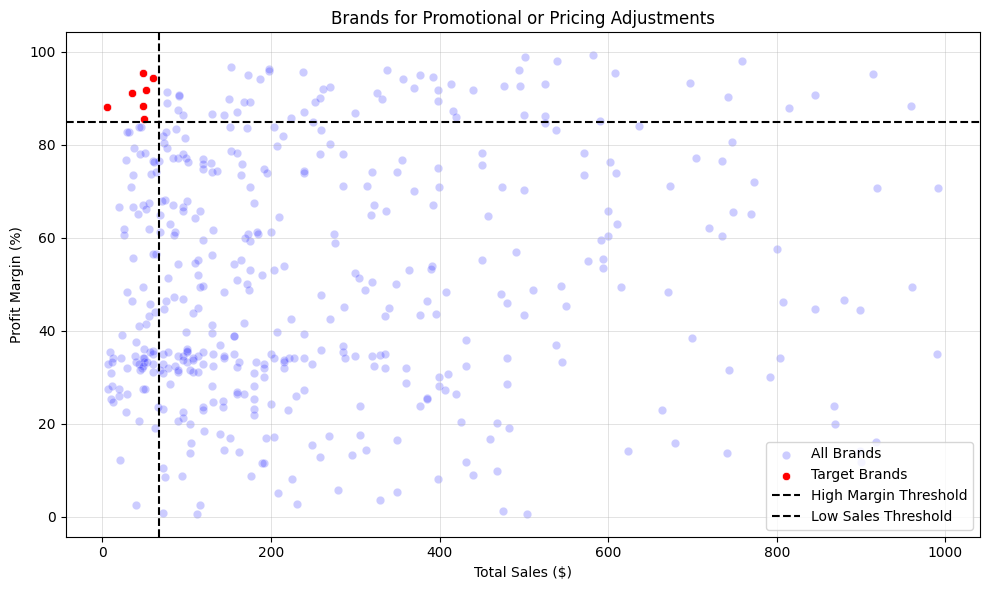

In [16]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=brand_performance,x = 'TotalSalesDollars' , y = 'ProfitMargin', color = 'blue',label = 'All Brands', alpha = 0.2)
sns.scatterplot(data=target_brands,x = 'TotalSalesDollars' , y = 'ProfitMargin', color = 'red',label = 'Target Brands')

plt.axhline(high_margin_threshold,linestyle = '--',color = 'black',label = "High Margin Threshold")
plt.axvline(low_sales_threshold,linestyle = '--',color = 'black',label = "Low Sales Threshold")

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### 2nd Research Question :- Which vendors and brands demonstrate the highest sales performance?

In [17]:
top_vendors = df.groupby("VendorName")['TotalSalesDollars'].sum().nlargest(10)
top_brands = df.groupby("Description")['TotalSalesDollars'].sum().nlargest(10)
top_vendors

VendorName
MARTIGNETTI COMPANIES         53290.90
ULTRA BEVERAGE COMPANY LLP    38431.17
M S WALKER INC                27422.84
BROWN-FORMAN CORP             23988.19
BACARDI USA INC               21242.26
DIAGEO NORTH AMERICA INC      18021.78
PERFECTA WINES                17347.99
PERNOD RICARD USA             15242.42
STATE WINE & SPIRITS          11477.65
SOUTHERN WINE & SPIRITS NE     9596.02
Name: TotalSalesDollars, dtype: float64

In [18]:
# To show the data in readable format
def format_dollars(value):
    if value >= 1000000:
        return f"{value/1000000:.2f}M"
    elif value >= 1000:
        return f"{value/1000:02f}K"
    else:
        return str(value)

In [19]:
top_vendors.apply(format_dollars)

VendorName
MARTIGNETTI COMPANIES         53.290900K
ULTRA BEVERAGE COMPANY LLP    38.431170K
M S WALKER INC                27.422840K
BROWN-FORMAN CORP             23.988190K
BACARDI USA INC               21.242260K
DIAGEO NORTH AMERICA INC      18.021780K
PERFECTA WINES                17.347990K
PERNOD RICARD USA             15.242420K
STATE WINE & SPIRITS          11.477650K
SOUTHERN WINE & SPIRITS NE     9.596020K
Name: TotalSalesDollars, dtype: str

In [20]:
print(top_vendors.index.name)

VendorName


In [21]:
top_brands.apply(format_dollars)

Description
Buehler Chard RRV               12.925220K
Bacardi Twin Pack 2/750mls       7.956020K
DiSaronna Amaretto Sour VAP      6.483020K
Robert Hall Cab Svgn             5.609990K
Jack Daniels Bruins Glass Pk     4.930380K
Baracchi O'Lillo                 4.640130K
Jack Daniels Honey + Glass       4.459090K
Parducci True Grit 11 Cab Sv     4.333290K
Capt Morgan White PET            4.317840K
Pavilion St Pierre Cdu Rhone     4.255740K
Name: TotalSalesDollars, dtype: str

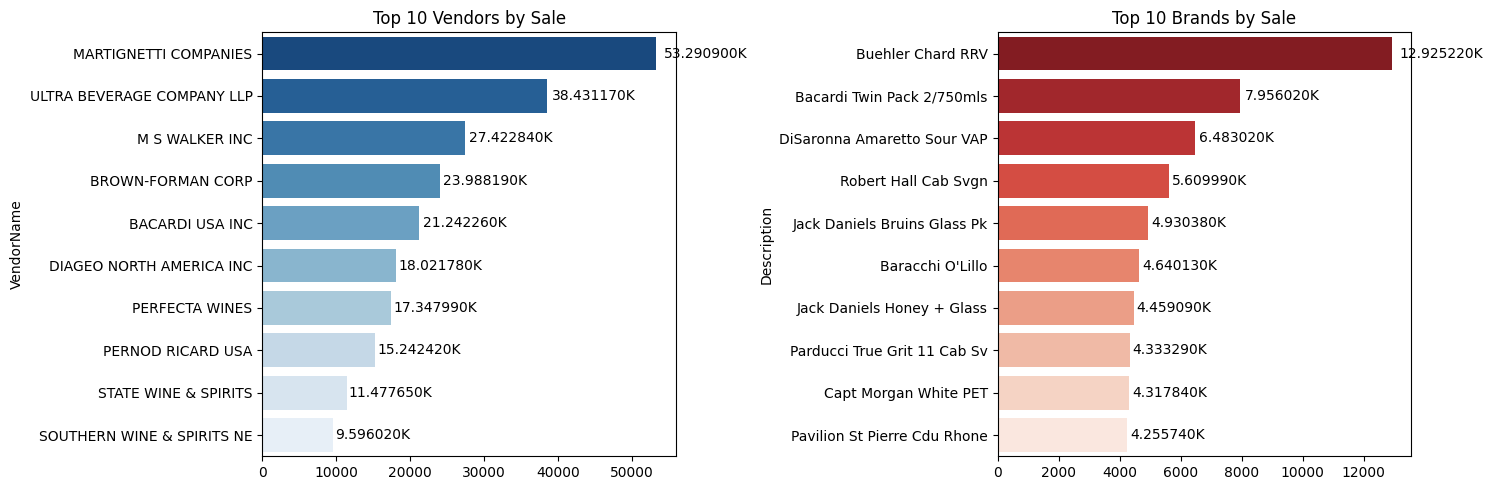

In [22]:
plt.figure(figsize=(15,5))

# Plot for Top Vendors
plt.subplot(1,2,1)
ax1 = sns.barplot(y=top_vendors.index,x=top_vendors.values,palette="Blues_r")
plt.title("Top 10 Vendors by Sale")

for bar in ax1.patches:
    ax1.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height() / 2,
             format_dollars(bar.get_width()),
             ha = 'left',va='center',fontsize = 10, color='black')


# Plot for Top Brands
plt.subplot(1,2,2)
ax2 = sns.barplot(y=top_brands.index.astype(str),x=top_brands.values,palette="Reds_r")
plt.title("Top 10 Brands by Sale")

for bar in ax2.patches:
    ax2.text(bar.get_width() + (bar.get_width() * 0.02),
             bar.get_y() + bar.get_height() / 2,
             format_dollars(bar.get_width()),
             ha = 'left',va='center',fontsize = 10, color='black')

plt.tight_layout()
plt.show()

#### 3rd Research Question:- Which vendors contribute the most to total purchase dollars

In [23]:
vendor_performance = df.groupby('VendorName').agg({
    'TotalPurchaseDollars':'sum',
    'GrossProfit':'sum',
    'TotalSalesDollars':'sum'
}).reset_index()
vendor_performance.shape

(61, 4)

In [24]:
vendor_performance['PurchaseContribution%'] = vendor_performance['TotalPurchaseDollars']/vendor_performance['TotalPurchaseDollars'].sum()*100

In [25]:
vendor_performance = round(vendor_performance.sort_values('PurchaseContribution%',ascending = False),2)

In [26]:
# Display Top10 Vendors

top_vendors = vendor_performance.head(10)
top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit'] = top_vendors['GrossProfit'].apply(format_dollars)
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
29,MARTIGNETTI COMPANIES,25.355840K,27.935060K,53.290900K,17.71
53,ULTRA BEVERAGE COMPANY LLP,15.148740K,23.282430K,38.431170K,10.58
26,M S WALKER INC,9.637070K,17.785770K,27.422840K,6.73
12,DIAGEO NORTH AMERICA INC,9.477400K,8.544380K,18.021780K,6.62
1,BACARDI USA INC,9.270960K,11.971300K,21.242260K,6.48
36,PERFECTA WINES,8.220620K,9.127370K,17.347990K,5.74
37,PERNOD RICARD USA,7.013320K,8.229100K,15.242420K,4.90
13,DISARONNO INTERNATIONAL LLC,5.679950K,1.731120K,7.411070K,3.97
46,STATE WINE & SPIRITS,5.324580K,6.153070K,11.477650K,3.72
3,BROWN-FORMAN CORP,4.658300K,19.329890K,23.988190K,3.25


In [27]:
print(top_vendors['PurchaseContribution%'].sum())

69.7


In [28]:
top_vendors['Cumulative_PurchaseContribution%'] = top_vendors['PurchaseContribution%'].cumsum()
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,Cumulative_PurchaseContribution%
29,MARTIGNETTI COMPANIES,25.355840K,27.935060K,53.290900K,17.71,17.71
53,ULTRA BEVERAGE COMPANY LLP,15.148740K,23.282430K,38.431170K,10.58,28.29
26,M S WALKER INC,9.637070K,17.785770K,27.422840K,6.73,35.02
12,DIAGEO NORTH AMERICA INC,9.477400K,8.544380K,18.021780K,6.62,41.64
1,BACARDI USA INC,9.270960K,11.971300K,21.242260K,6.48,48.12
36,PERFECTA WINES,8.220620K,9.127370K,17.347990K,5.74,53.86
37,PERNOD RICARD USA,7.013320K,8.229100K,15.242420K,4.90,58.76
13,DISARONNO INTERNATIONAL LLC,5.679950K,1.731120K,7.411070K,3.97,62.73
46,STATE WINE & SPIRITS,5.324580K,6.153070K,11.477650K,3.72,66.45
3,BROWN-FORMAN CORP,4.658300K,19.329890K,23.988190K,3.25,69.70


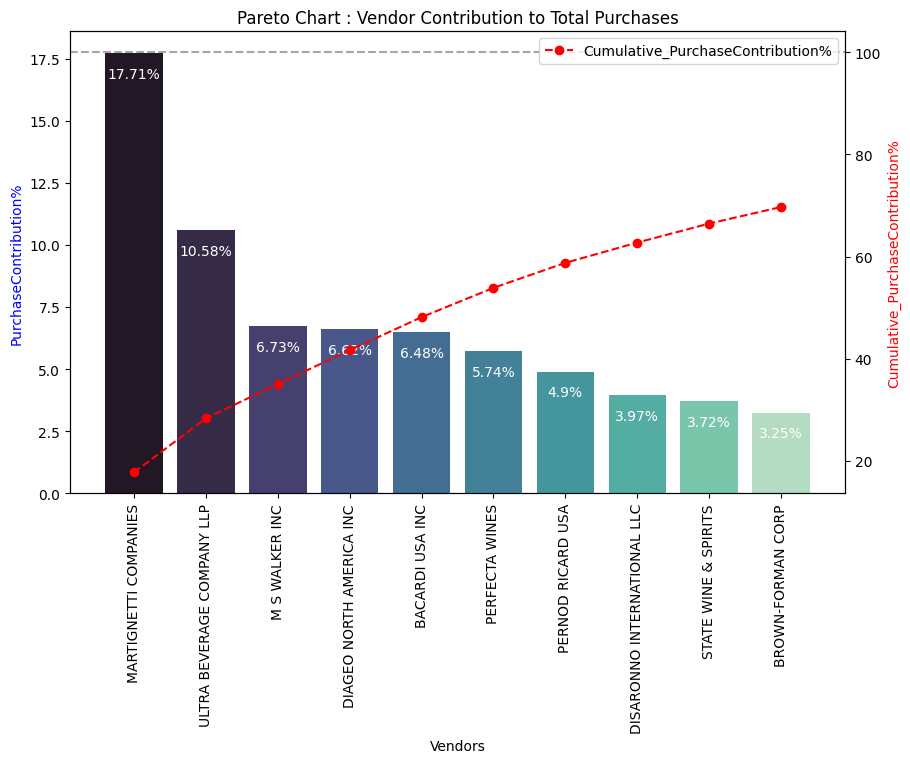

In [29]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for purchase contribution%
sns.barplot(x=top_vendors['VendorName'], y=top_vendors['PurchaseContribution%'], palette='mako', ax=ax1)

for i, value in enumerate(top_vendors['PurchaseContribution%']):
    ax1.text(i, value - 1, str(value) + '%', ha='center', fontsize=10, color='white')

# Line plot for Cumulative contribution%
ax2 = ax1.twinx()
ax2.plot(top_vendors['VendorName'], top_vendors['Cumulative_PurchaseContribution%'], color='red', marker='o',
         linestyle='dashed', label='Cumulative_PurchaseContribution%')

ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)
ax1.set_ylabel('PurchaseContribution%', color='blue')
ax2.set_ylabel('Cumulative_PurchaseContribution%', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart : Vendor Contribution to Total Purchases')

ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)
ax2.legend(loc='upper right')

plt.show()

#### 4th Research Question:- How much of total procurement is dependent on the top vendors

In [30]:
print(f"Total Purchase COntribution of top 10 Vendors is {round(top_vendors['PurchaseContribution%'].sum(),2)}%")

Total Purchase COntribution of top 10 Vendors is 69.7%


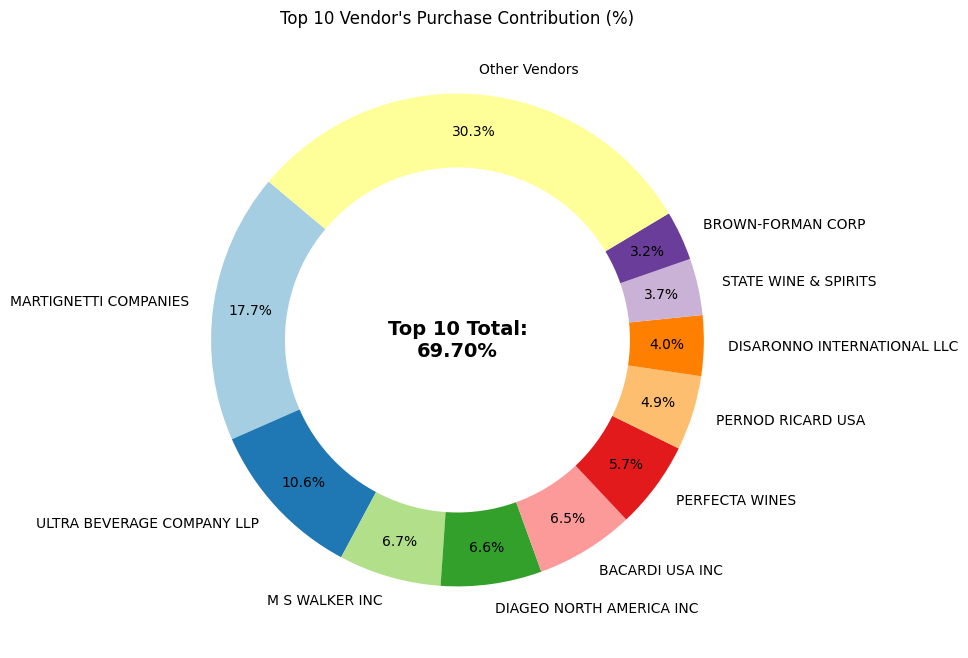

In [31]:
vendors = list(top_vendors['VendorName'].values)
purchase_contrubutions = list(top_vendors['PurchaseContribution%'].values)
total_contribution = sum(purchase_contrubutions)
remaining_contributions = 100 - total_contribution

# Append "Other Vendors" category
vendors.append("Other Vendors")
purchase_contrubutions.append(remaining_contributions)

# Donut chart
fig,ax = plt.subplots(figsize=(10,8))
wedges,texts,autotexts = ax.pie(purchase_contrubutions,labels = vendors,autopct='%1.1f%%',
                                startangle=140,pctdistance=0.85,colors=plt.cm.Paired.colors)

# Draw a white circle in the center to create a donut effect
center_circle = plt.Circle((0,0),0.70,fc='white')
fig.gca().add_artist(center_circle)

# Add total contribution annotation in the center
plt.text(0,0,f"Top 10 Total:\n{total_contribution:.2f}%",fontsize=14,fontweight='bold',ha='center',va='center')

plt.title("Top 10 Vendor's Purchase Contribution (%)")
plt.show()

#### 5th Research Question :- Does purchasing in bulk reduce the unit price,and what is the optimal purchase volume for cost savings?

In [32]:
df['UnitPurchasePrice'] = df['TotalPurchaseDollars']/df['TotalPurchaseQuantity']

In [33]:
# Divide TotalPurchaseQuantity in 3 category(large,medium,small) on quantile basis using pd.qcut:- it creates 3 eqaul bucket and will save in order size

df['OrderSize'] = pd.qcut(df['TotalPurchaseQuantity'],q=3,labels=['small','Medium','Large'])

In [34]:
print(df[['OrderSize','TotalPurchaseQuantity']])

    OrderSize  TotalPurchaseQuantity
0       Large                    383
1       Large                    690
2       Large                    282
3       Large                    418
4       Large                    370
..        ...                    ...
545    Medium                      6
546     small                      1
547     small                      2
548     small                      3
549     small                      1

[550 rows x 2 columns]


In [35]:
df.groupby('OrderSize')['UnitPurchasePrice'].mean()

OrderSize
small     25.624412
Medium    16.906391
Large     10.241525
Name: UnitPurchasePrice, dtype: float64

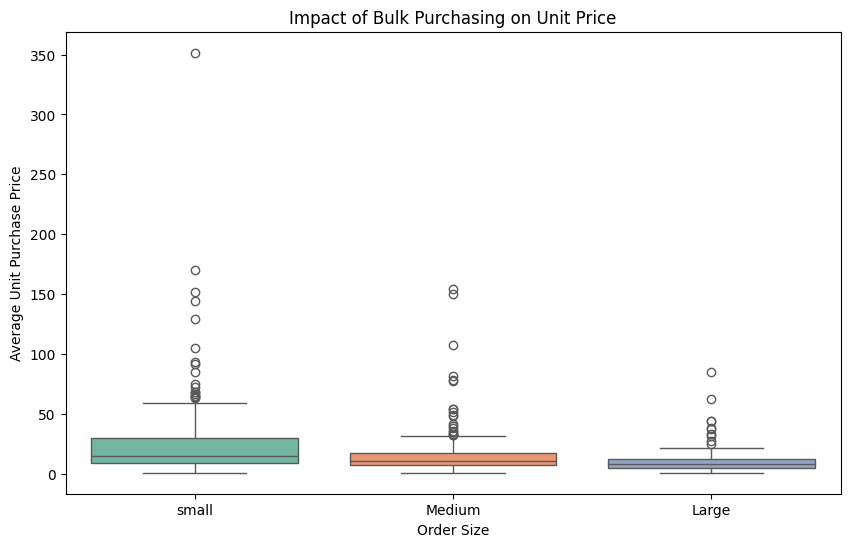

In [36]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='OrderSize',y='UnitPurchasePrice',palette='Set2')
plt.title('Impact of Bulk Purchasing on Unit Price')
plt.xlabel('Order Size')
plt.ylabel('Average Unit Purchase Price')
plt.show()

##### Some Insights:-

* Vendors buying in bulk(Large Order Size) get the lowest unit price,meaning higher margins if they can manage inventory efficiently.
* The price difference between Small and large orders is substantial(~72% reduction in unt cost)
* This suggests that bulk pricing strategies successfully vendors to purchase in larger volume,leading to higher overall sales despite lower per-unit revenue.

#### 6th Research Question:- Which Vendors have low inventory turnover,indicating excess stock and slow-moving products?

In [43]:
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover',ascending=True).head(10)
result

VendorName
CONSTELLATION BRANDS INC      0.568202
PSP WINES                     0.673469
PROXIMO SPIRITS INC.          0.700000
BANFI PRODUCTS CORP           0.705882
DELICATO VINEYARDS INC        0.711111
Dunn Wine Brokers             0.719697
PALM BAY INTERNATIONAL INC    0.722222
DIAGEO NORTH AMERICA INC      0.750000
VINILANDIA USA                0.750000
PINE STATE TRADING CO         0.756452
Name: StockTurnover, dtype: float64

#### 7th Research Question :- How much capital is locked in unsold inventory per vendor,and which vendors contribute the most to it


In [44]:
df['UnsoldInventoryValue'] = (df['TotalPurchaseQuantity'] - df['TotalSalesQuantity'])*df['PurchasePrice']
print('Total Unsold Capital:',format_dollars(df['UnsoldInventoryValue'].sum()))

Total Unsold Capital: -87600.01999999999


In [53]:
# Aggregate Capital Locked per Vendor
inventory_value_per_vendor = df.groupby('VendorName')['UnsoldInventoryValue'].sum().reset_index()

# Sort Vendors with the highest Locked Capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(by='UnsoldInventoryValue',ascending=False)
inventory_value_per_vendor['UnsoldInventoryValue'] = inventory_value_per_vendor['UnsoldInventoryValue'].apply(format_dollars)
inventory_value_per_vendor.head(10)
result

VendorName
CONSTELLATION BRANDS INC      0.568202
PSP WINES                     0.673469
PROXIMO SPIRITS INC.          0.700000
BANFI PRODUCTS CORP           0.705882
DELICATO VINEYARDS INC        0.711111
Dunn Wine Brokers             0.719697
PALM BAY INTERNATIONAL INC    0.722222
DIAGEO NORTH AMERICA INC      0.750000
VINILANDIA USA                0.750000
PINE STATE TRADING CO         0.756452
Name: StockTurnover, dtype: float64

#### 8th Research Question:- What is the 95% confidence intervals for profit margins of top-performing and low-performing vendors


In [54]:
top_threshold = df['TotalSalesDollars'].quantile(0.75)
low_threshold = df['TotalSalesDollars'].quantile(0.25)
print('top_threshold:',top_threshold)
print('low_threshold:',low_threshold)

top_threshold: 588.635
low_threshold: 99.9825


In [55]:
top_vendors = df[df['TotalSalesDollars'] >= top_threshold]['ProfitMargin'].dropna()
low_vendors = df[df['TotalSalesDollars'] <= low_threshold]['ProfitMargin'].dropna()

In [56]:
low_vendors

289     8.738481
306    21.256643
311    22.556391
317    20.587254
319     0.876095
         ...    
545    91.766724
546    94.323873
547    91.122278
548    95.485467
549    88.047138
Name: ProfitMargin, Length: 138, dtype: float64

In [58]:
# To Calculate the confidence interval

def confidence_interval(data,confidence=0.95):
    mean_val = np.mean(data)
    standard_error = np.std(data,ddof=1) / np.sqrt(len(data))
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) -1)
    margin_of_error = t_critical * standard_error
    return mean_val,mean_val-margin_of_error,mean_val+margin_of_error

Top Vendors 95% CI: (54.44,62.99),Mean:58.72
Low Vendors 95% CI: (47.07,55.19),Mean:51.13


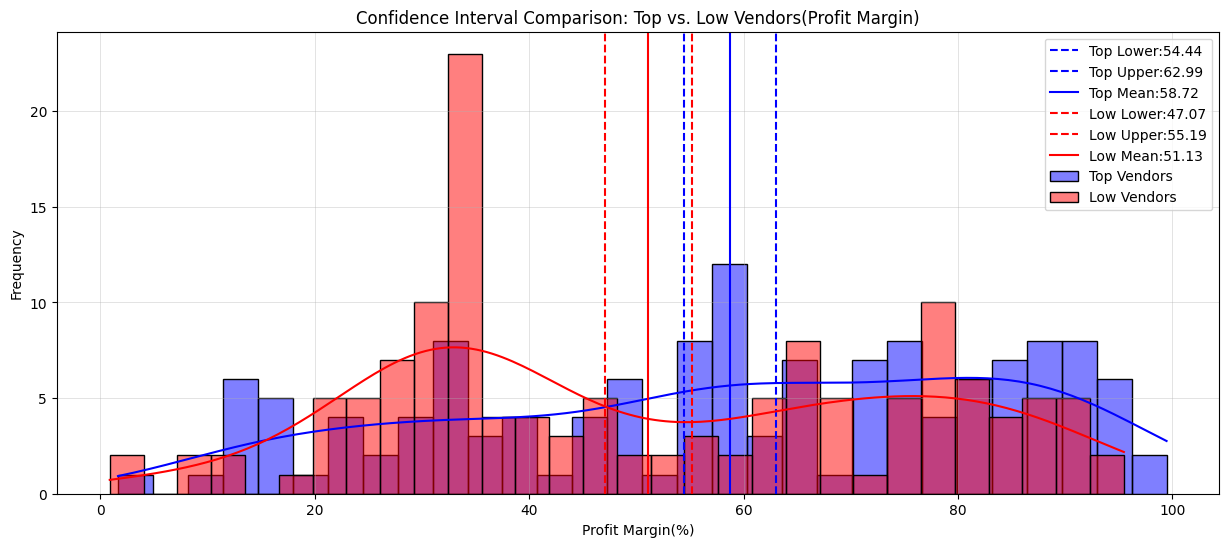

In [59]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)


print(f"Top Vendors 95% CI: ({top_lower:.2f},{top_upper:.2f}),Mean:{top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f},{low_upper:.2f}),Mean:{low_mean:.2f}")

plt.figure(figsize=(15,6))

# Top Vendors Plot
sns.histplot(top_vendors,kde=True,color='blue',bins=30,alpha=0.5,label='Top Vendors')
plt.axvline(top_lower,color='blue',linestyle='--',label=f"Top Lower:{top_lower:.2f}")
plt.axvline(top_upper,color='blue',linestyle='--',label=f"Top Upper:{top_upper:.2f}")
plt.axvline(top_mean,color='blue',linestyle='-',label=f"Top Mean:{top_mean:.2f}")

# Low Vendors Plot
sns.histplot(low_vendors,kde=True,color='red',bins=30,alpha=0.5,label='Low Vendors')
plt.axvline(low_lower,color='red',linestyle='--',label=f"Low Lower:{low_lower:.2f}")
plt.axvline(low_upper,color='red',linestyle='--',label=f"Low Upper:{low_upper:.2f}")
plt.axvline(low_mean,color='red',linestyle='-',label=f"Low Mean:{low_mean:.2f}")

# Finalize Plot
plt.title("Confidence Interval Comparison: Top vs. Low Vendors(Profit Margin)")
plt.xlabel("Profit Margin(%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

##### Insights:-
* The confidence interval for low-performing vendors(40.48% to 42.62%) is significantly higher than that of top-performing vendors (30.74% to 31.61%)
* This suggests that vendors with lower sales tend to maintain higher profit margins,potentialy due to premium pricing or lower operational costs.
* For High-Performing Vendors:- If they aim to improve profitabilty,they could explore selective price adjustment,cost optimization,or bundling strategis.
* For Low-Perfoming Vendors:- Despite higher margins,their low sales volume might indicate a need for better marketing,competitve pricing,or improved distribution strategies.

#### Is there a significant difference in profit margins between top-performing and low-performing vendors?

#### Hypothesis:

##### H0(Null Hypothesis):- There is no significant difference in the mean profit margins of top-performing and low-performing vendors.

##### H1(Alternative Hypothesis):- The mean profit margins of top-performing and low-performing vendors are significantly different.

In [60]:
top_threshold = df['TotalSalesDollars'].quantile(0.75)
low_threshold = df['TotalSalesDollars'].quantile(0.25)

top_vendors = df[df['TotalSalesDollars'] >= top_threshold]['ProfitMargin'].dropna()
low_vendors = df[df['TotalSalesDollars'] <= low_threshold]['ProfitMargin'].dropna()

# Perfomr Two-Sample T-Test
t_start, p_value = ttest_ind(top_vendors,low_vendors,equal_var=False)

# Print result
print(f"T-Statistic: {t_start:.4f}, p-Value: {p_value: .4f}")
if p_value < 0.05:
    print("Reject H0:- There is a significant difference in profit margin between top and low-performing vendors.")
else:
    print("Fail to reject H0:- No significant difference in profit margin.")

T-Statistic: 2.5414, p-Value:  0.0116
Reject H0:- There is a significant difference in profit margin between top and low-performing vendors.
